# Практическое занятие №5: Прототип оценки стоимости домов

**Задача:** Регрессия — прогнозирование медианной стоимости домов в Калифорнии.  
**Датасет:** California Housing (scikit-learn)  
**Модели:** LinearRegression, DecisionTreeRegressor

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings; warnings.filterwarnings('ignore')

## 1. Исследование данных и целевой переменной

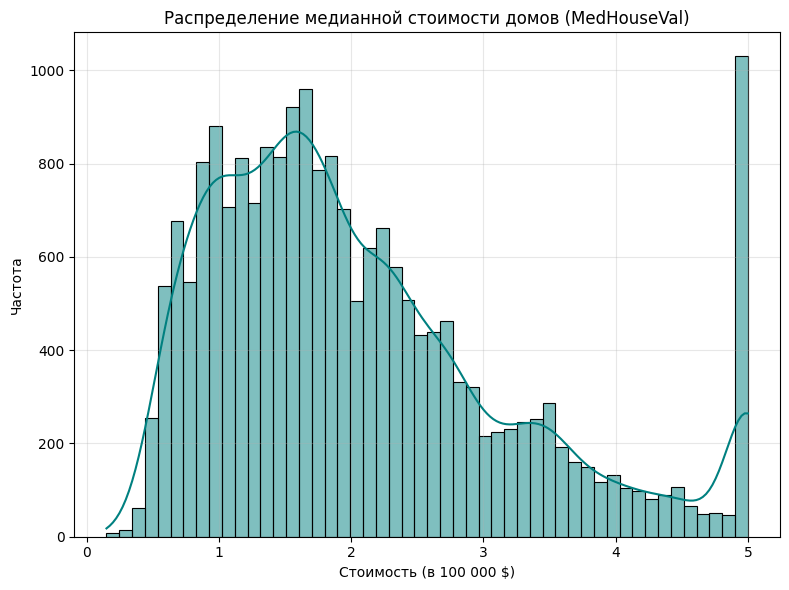

In [2]:
california = fetch_california_housing()
X_full = pd.DataFrame(california.data, columns=california.feature_names)
y = pd.Series(california.target, name='MedHouseVal')

plt.figure(figsize=(8, 6))
sns.histplot(y, bins=50, kde=True, color='teal')
plt.title('Распределение медианной стоимости домов (MedHouseVal)')
plt.xlabel('Стоимость (в 100 000 $)')
plt.ylabel('Частота')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('target_histogram.png')
plt.show()

Выбраны признаки для анализа: ['MedInc', 'AveRooms']
 - MedInc: Медианный доход в районе
 - AveRooms: Среднее количество комнат


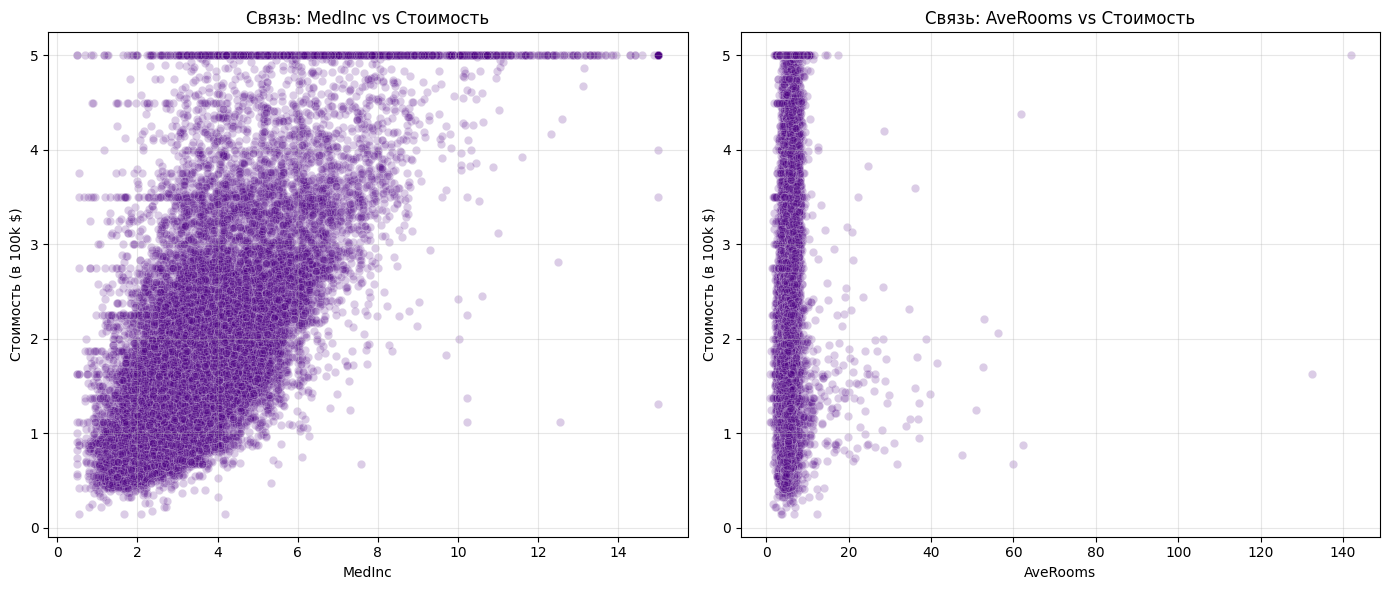

In [3]:
selected_features = ['MedInc', 'AveRooms']
print(f"Выбраны признаки для анализа: {selected_features}")
print(" - MedInc: Медианный доход в районе")
print(" - AveRooms: Среднее количество комнат")

X = X_full[selected_features]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for i, feature in enumerate(selected_features):
    sns.scatterplot(x=X[feature], y=y, alpha=0.2, ax=axes[i], color='indigo')
    axes[i].set_title(f'Связь: {feature} vs Стоимость')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Стоимость (в 100k $)')
    axes[i].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('features_vs_target.png')
plt.show()

## 2. Обучение и оценка линейной модели

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Линейная регрессия (LinearRegression):")
print(f"  MAE: {mae_lr:.4f}")
print(f"  MSE: {mse_lr:.4f}")
print(f"  R2:  {r2_lr:.4f}")

print("\nИнтерпретация коэффициентов:")
for feature, coef in zip(selected_features, lr.coef_):
    print(f"  Коэффициент [{feature}]: {coef:.4f}")
print(f"  Intercept (Смещение): {lr.intercept_:.4f}")
print("\nБизнес-интерпретация для заказчика:")
print(f"Увеличение показателя 'AveRooms' (средняя комнатность) на 1 единицу приводит "
      f"к изменению прогнозируемой стоимости дома в среднем на {lr.coef_[1] * 100:.2f} тысяч долларов "
      f"(при условии неизменности дохода).")

Линейная регрессия (LinearRegression):
  MAE: 0.6172
  MSE: 0.6826
  R2:  0.4799

Интерпретация коэффициентов:
  Коэффициент [MedInc]: 0.4336
  Коэффициент [AveRooms]: -0.0371
  Intercept (Смещение): 0.5897

Бизнес-интерпретация для заказчика:
Увеличение показателя 'AveRooms' (средняя комнатность) на 1 единицу приводит к изменению прогнозируемой стоимости дома в среднем на -3.71 тысяч долларов (при условии неизменности дохода).


## 3. Сравнение с нелинейной моделью

In [5]:
dt = DecisionTreeRegressor(max_depth=3, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print(f"Дерево решений (DecisionTreeRegressor, max_depth=3):")
print(f"  MAE: {mae_dt:.4f}")
print(f"  R2:  {r2_dt:.4f}")

Дерево решений (DecisionTreeRegressor, max_depth=3):
  MAE: 0.6295
  R2:  0.4683


## Итоговое сравнение моделей

                Модель    MAE R2 Score
      LinearRegression 0.6172   0.4799
DecisionTree (depth=3) 0.6295   0.4683

Для финального графика выбрана модель: LinearRegression


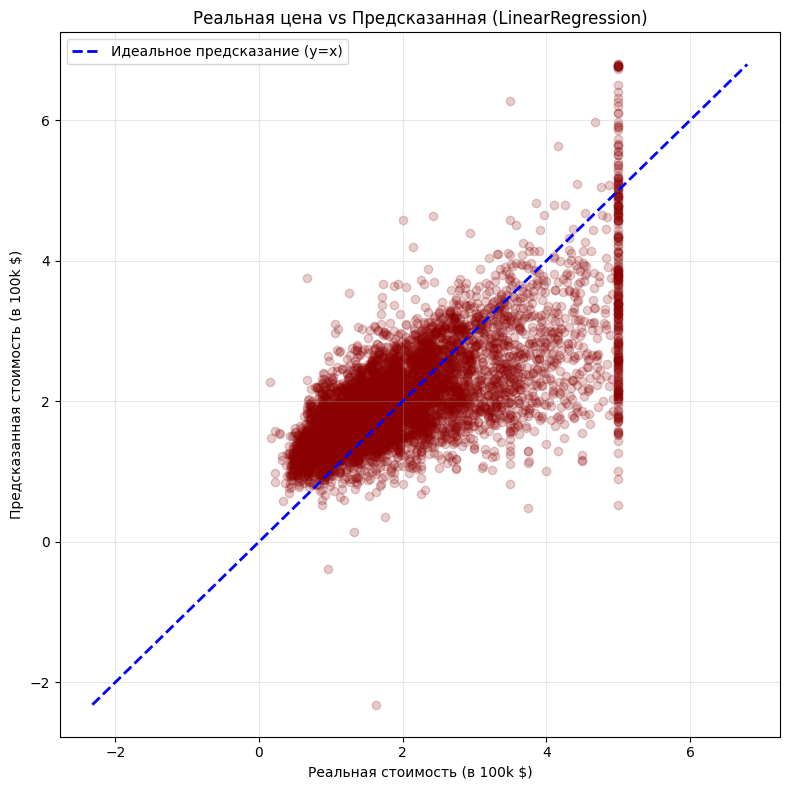

In [6]:
data = [
    ['LinearRegression', f"{mae_lr:.4f}", f"{r2_lr:.4f}"],
    ['DecisionTree (depth=3)', f"{mae_dt:.4f}", f"{r2_dt:.4f}"]
]
comp_df = pd.DataFrame(data, columns=['Модель', 'MAE', 'R2 Score'])
print(comp_df.to_string(index=False))

best_model_name = "LinearRegression" if r2_lr > r2_dt else "DecisionTreeRegressor"
best_preds = y_pred_lr if best_model_name == "LinearRegression" else y_pred_dt
print(f"\nДля финального графика выбрана модель: {best_model_name}")

plt.figure(figsize=(8, 8))
plt.scatter(y_test, best_preds, alpha=0.2, color='darkred')
min_val = min(y.min(), best_preds.min())
max_val = max(y.max(), best_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], 'b--', lw=2, label='Идеальное предсказание (y=x)')
plt.title(f'Реальная цена vs Предсказанная ({best_model_name})')
plt.xlabel('Реальная стоимость (в 100k $)')
plt.ylabel('Предсказанная стоимость (в 100k $)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('real_vs_pred_scatter.png')
plt.show()